## Clustering gene dynamics 

Here, the responding genes (DEGs as found in gene_list_DEA_ABCD.tsv) are clustered based on their dynamics in the (discrete) experimental time points. 

In [1]:
### loading python libraries

# standard libraries
import numpy as np
import pandas as pd

# single cell libraries
import scanpy as sc
sc.settings.verbosity = 0

# plotting libraries
from matplotlib import pyplot as plt

### for timeseries clustering
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from sklearn.cluster import KMeans

# other
import math #to round up
import warnings
warnings.filterwarnings('ignore') #ignore filter warnings

# own libraries
from plotting import *

In [2]:
### load single-cell dataset
adata_path = "/fast/AG_Pombo/luna/2023_vta_multiome/2024/1_GEX/8_240510_GEX_memory_only_v2/1_240529_GEX_kmeans/240530.DNs.VTA.RNA.seu.sub.data.893.h5ad"
adata = sc.read_h5ad(adata_path)

In [3]:
### merge control (saline) treatment into one timepoint
control_mask = adata.obs["treatment"] == 'saline'
adata.obs.loc[control_mask, 'timepoint'] = 'control'
adata.obs["timepoint"] = adata.obs["timepoint"].astype('category')

In [4]:
### set order of timepoints
new_order = ['control','h24','d14']
adata.obs["timepoint"] = adata.obs["timepoint"].cat.reorder_categories(new_order)

In [5]:
### make replicate categorical
adata.obs["replicate"] = adata.obs["replicate"].astype('category')

In [6]:
### load degs
degs_path = "/fast/AG_Pombo/luna/2023_vta_multiome/2024/1_GEX/8_240510_GEX_memory_only_v2/1_240529_GEX_kmeans/240529_vta.late.DEGs.txt"
degs_df = pd.read_csv(degs_path, sep='\t')
degs = degs_df.iloc[:,0].to_numpy()

In [7]:
### calculate average expression in other timepoints
obs = adata[:,degs].X.toarray()
obs = pd.DataFrame(obs,columns=degs,index=adata.obs["timepoint"])
obs_average = obs.groupby(level=0).mean()

In [8]:
obs_average
obs_average2 = obs_average

In [9]:
index = ['control', 'h24', 'd14']

# Calculate midpoints and add new rows
midpoints = ['control.h24', 'h24.d14']

for idx, midpoint in enumerate(midpoints):
    timepoints = midpoint.split('.')
    time1, time2 = timepoints[0], timepoints[1]
    
    # Calculate the midpoint values
    midpoint_values = obs_average2.loc[time1] + (obs_average2.loc[time2] - obs_average2.loc[time1]) / 2
    
    # Add new row to the dataframe
    obs_average2.loc[midpoint] = midpoint_values

# Specify the desired order of rows
desired_order = ['control', 'control.h24', 'h24', 'h24.d14', 'd14']

# Reorder rows
obs_average2 = obs_average2.loc[desired_order]

# Display the new dataframe
print(obs_average2)

               Mrpl15    Pcmtd1   Ppp1r42     Prex2   Gm38033     Zap70  \
timepoint                                                                 
control      0.119076  0.812997  0.014840  0.137883  0.000000  0.000000   
control.h24  0.084491  0.748985  0.007420  0.103360  0.003577  0.009794   
h24          0.049906  0.684974  0.000000  0.068837  0.007155  0.019587   
h24.d14      0.056604  0.717386  0.017618  0.082132  0.008339  0.014019   
d14          0.063302  0.749797  0.035236  0.095427  0.009524  0.008450   

                Npas2     Gulp1    Dnah7b    Dnah7a  ...      Nkap     Mbnl3  \
timepoint                                            ...                       
control      0.069616  0.148932  0.340382  0.101815  ...  0.058312  0.009639   
control.h24  0.079620  0.180661  0.307609  0.079960  ...  0.055199  0.004819   
h24          0.089624  0.212390  0.274836  0.058106  ...  0.052086  0.000000   
h24.d14      0.086184  0.175872  0.268064  0.081114  ...  0.071649  0.0143

In [10]:
### scale the average expression
obs_average2 = (obs_average2 - obs_average2.min())/(obs_average2.max() - obs_average2.min())

In [11]:
### create usuable format for time series
formatted_dataset = to_time_series_dataset(obs_average2.T.values.tolist())
formatted_dataset.shape #check that dataset is right size (3D)

(1771, 5, 1)

In [12]:
formatted_dataset_trans = obs_average2.transpose()
scaled_df = formatted_dataset_trans
scaled_df.shape

(1771, 5)

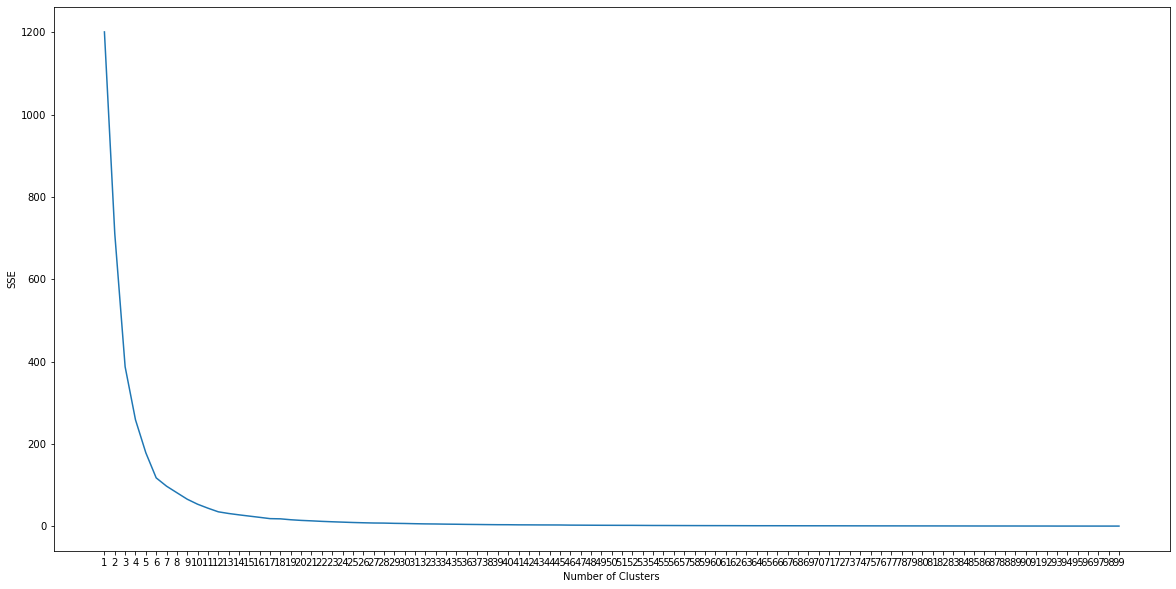

In [13]:
#Elbow:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 15,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 100):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(20, 10))
#visualize results
plt.plot(range(1, 100), sse)
plt.xticks(range(1, 100))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

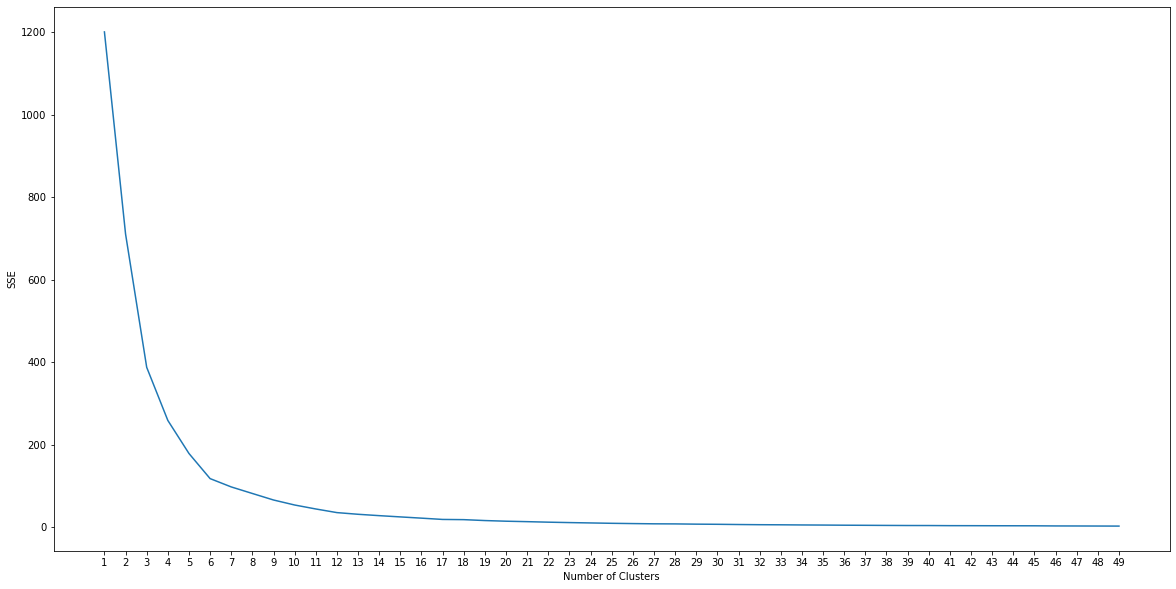

In [16]:
#create list to hold SSE values for each k
sse = []
for k in range(1, 50):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(20, 10))
#visualize results
plt.plot(range(1, 50), sse)
plt.xticks(range(1, 50))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [15]:
### cluster DEGs
seed = 0
np.random.seed(seed)

n_clust = 50 #preselect number of clusters

kmeans = TimeSeriesKMeans(n_clusters=n_clust, max_iter=15, random_state=seed)
y_pred = kmeans.fit_predict(formatted_dataset)

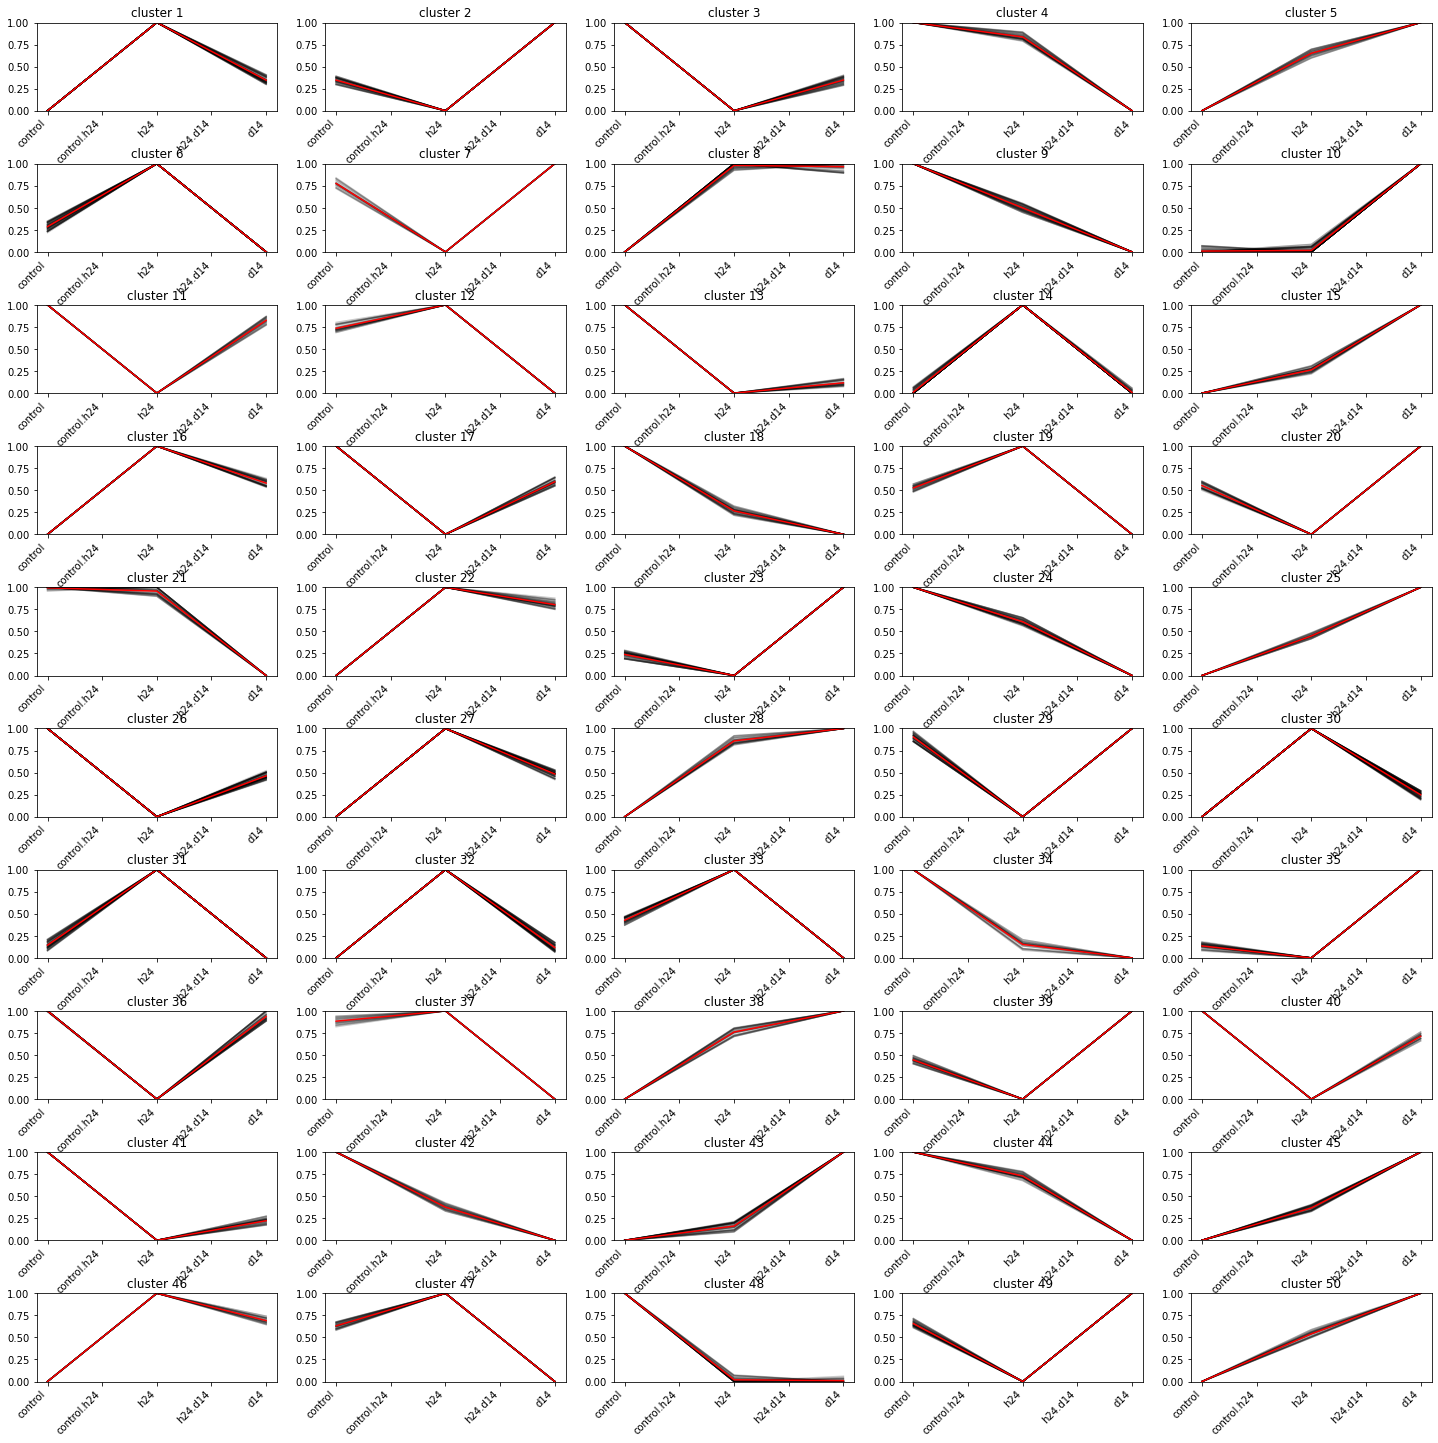

In [16]:
### plot clusters
fig, axs = plt.subplots(math.ceil(n_clust/5), 5,
                            figsize = (25,2.5*math.ceil(n_clust/5)),
                            gridspec_kw={'wspace':0.2, 'hspace':0.6})
axs = axs.ravel()
xticks = np.arange(len(desired_order))

for cluster in range(n_clust):

    for xx in formatted_dataset[y_pred == cluster]:
        axs[cluster].plot(xx.ravel(), "k-", alpha=.2)
    axs[cluster].plot(kmeans.cluster_centers_[cluster].ravel(), "r-")
    axs[cluster].set_ylim([0, 1])
    axs[cluster].set_xticks(xticks)
    axs[cluster].set_xticklabels(desired_order, rotation=45, ha='right')  
    #axs[cluster].set_xlim([0, 11])
    #axs[cluster].set_xticklabels(adata.obs["timepoint"].cat.categories)
    
    axs[cluster].title.set_text('cluster %d' % (cluster + 1))

### save figure
#save_path = "/fast/AG_Pombo/luna/2023_vta_multiome/2024/1_GEX/8_240510_GEX_memory_only_v2/1_240529_GEX_kmeans/240530_lateDARs_50clusters.png"
#fig.savefig(save_path, bbox_inches='tight', format='png', dpi=300)
    
#plt.show()

In [ ]:
# Define clusters of interest (change these based on your selection)
clusters_of_interest = [1, 11, 8, 48, 15, 4]  # Example: Change this list to your desired clusters
clusters_of_interest = [c - 1 for c in clusters_of_interest]

xticks = np.arange(len(desired_order))

for cluster in clusters_of_interest:
    fig, ax = plt.subplots(figsize=(5, 2.5))  # Adjust figure size for individual plots

    # Plot all data points in the cluster
    for xx in formatted_dataset[y_pred == cluster]:
        ax.plot(xx.ravel(), "k-", alpha=0.2)

    # Plot cluster centroid
    ax.plot(kmeans.cluster_centers_[cluster].ravel(), "r-")

    # Formatting
    ax.set_ylim([0, 1])
    ax.set_xticks(xticks)
    ax.set_xticklabels(desired_order, rotation=45, ha='right')
    ax.set_title(f'Cluster {cluster + 1}')

    # Save figure
#    save_path = f"/fast/AG_Pombo/luna/2025_pdf_files/gene_dynamics_pdf/memory_clusters/kmeans_cluster_{cluster + 1}.pdf"  # Update with your directory
#    fig.savefig(save_path, bbox_inches='tight', format='pdf', dpi=300)
#    plt.close(fig)  # Close figure to avoid memory issues

print("Plots saved successfully!")

In [18]:
### make dictionary with names of genes in each cluster
dynamic_cluster_dict = {}

for cluster in range(n_clust):
    dynamic_cluster_dict[f"cluster{str(cluster+1)}"] = degs[y_pred == cluster]

In [19]:
### print genes in cluster of interest
dynamic_cluster_dict['cluster18']

array(['Cntrl', 'Myo3b', 'Lnx1', 'Nup205', 'Olfr691', 'Gm47578', 'Shisa6',
       'Efcab1', 'Ly96', '9230116N13Rik', 'Gm43445', 'Coq3', 'Azin2',
       'Gucy2c', 'Gm45486', 'Ipo7', 'Gm17387', 'Gm15816', 'Sall1',
       'Gm45464', 'Gm45894', '9330154J02Rik', 'Zcwpw2', 'Gm16998',
       'Stk11', 'Acss3', 'Nprl3', 'Ptgr2', 'Lrtm1', 'Gpalpp1', 'Gm6999',
       'Rspo2', 'Pcdhgb7'], dtype=object)

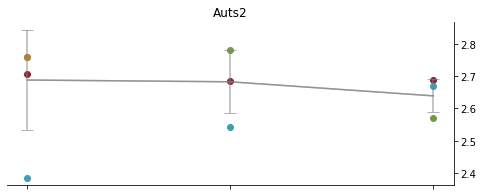

In [20]:
plot_gene_in_time(adata, 'Auts2')

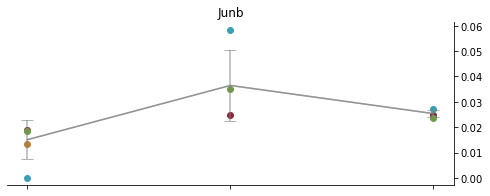

In [21]:
plot_gene_in_time(adata, 'Junb')

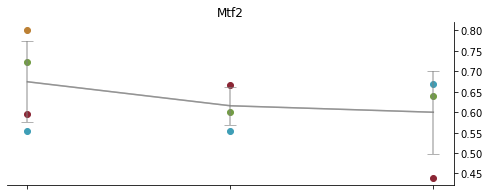

In [22]:
plot_gene_in_time(adata, 'Mtf2')

In [24]:
#Code by Luna:
#I want to convert the dictionary to a dataframe and save it. 
dynamic_cluster_df = pd.DataFrame.from_dict(dynamic_cluster_dict, 'index').stack().reset_index(level=0)
dynamic_cluster_df[0] = dynamic_cluster_df[0].str.replace('-', ':', 1)

#Save it:
dynamic_cluster_df.to_csv('240530_dynamic_cluster_df_version2.csv', index=False)  # Set index=False to exclude the index column